# Concrete column

This example implements a 3D cantilever column analysis.
The model uses one `ForceFrame` element, a rectangular reinforced-concrete
fiber section, a constant axial load, and a cyclic biaxial tip displacement
path.


{download}`Download <frame-2005.ipynb>`

In [1]:

from math import pi, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import veux
import xara
from xara.units.iks import inch, foot, ksi, kip
from xsection import CompositeSection
from xsection.library import Circle, Rectangle

## Model

The column is 8 ft tall. The section is an 18 in by 18 in reinforced concrete
section with eight #8 bars. The imposed lateral displacement amplitude is
0.5 percent drift for the first cycle, followed by two and three times that
amplitude.

In [2]:
BASE_NODE = 1
TIP_NODE = 2
TRANSFORM_TAG = 1

L = 8.0 * foot

section_width = 18.0 * inch
section_depth = 18.0 * inch
cover = 1.5 * inch

fc = 5.0 * ksi
fy = 68.0 * ksi
Es = 29_000.0 * ksi

bar_area = 0.79 * inch**2
bar_radius = sqrt(bar_area / pi)

axial_load_ratio = 0.30
base_drift = 0.005
cycle_factors = [1.0, 2.0, 3.0]
points_per_cycle = 100
ramp_steps = 10

### Materials and fiber section

`Concrete01` is used for both the confined core and the cover. The parameters
are intentionally simple. The core has a modest confinement increase, while
the cover uses unconfined concrete. The reinforcing steel uses a bilinear
`Steel01` material.

In [3]:
materials = {
    "core": xara.UniaxialMaterial(
        type="Concrete01",
        Fc=-1.05 * fc,
        nu=0.2,
        ec0=-0.0035,
        Fcu=-0.80 * fc,
        ecu=-0.014,
    ),
    "cover": xara.UniaxialMaterial(
        type="Concrete01",
        Fc=-fc,
        nu=0.2,
        ec0=-0.002,
        Fcu=-0.20 * fc,
        ecu=-0.006,
    ),
    "rebar": xara.UniaxialMaterial(
        type="Steel01",
        nu=0.3,
        E=Es,
        Fy=fy,
        b=0.01,
    ),
}

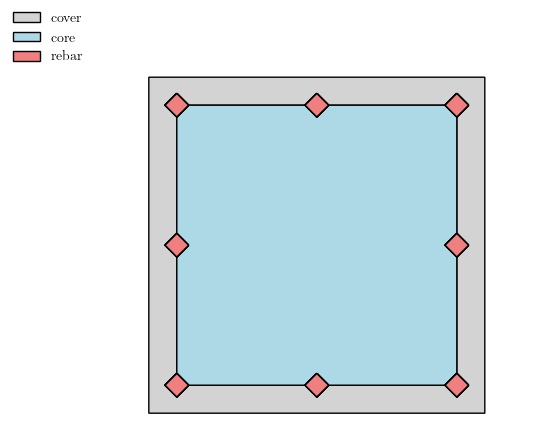

In [4]:
def create_shape(materials):
    """Create the section geometry."""

    bar = Circle(
        radius=bar_radius,
        z=2,
        material=materials["rebar"],
        group="rebar",
        divisions=4,
        mesh_scale=0.5,
    )

    b = section_width
    h = section_depth
    c = cover

    shape = CompositeSection([
                Rectangle(    b, h,     z=0, group="cover", material=materials["cover"]),
                Rectangle(b-2*c, h-2*c, z=1, group="core", material=materials["core"]),
                *bar.linspace([-b/2+c, -h/2+c], [ b/2-c,-h/2+c], 3), # Top bars
                *bar.linspace([-b/2+c,      0], [ b/2-c,     0], 2), # Center bars
                *bar.linspace([-b/2+c,  h/2-c], [ b/2-c, h/2-c], 3)  # Bottom bars
            ])

    return shape

shape = create_shape(materials)
veux.draw_shape(shape)

### Assembly

The element axis is global $Y$. 
The linear transformation uses `vecxz=(1,0,0)`,
which makes the local $y$ axis parallel to global $Z$ and the local $z$ axis
parallel to global $X$.

In [5]:
def add_path_sp(model, pattern: int, series: int, node: int, dof: int, values) -> None:
    """Apply a prescribed displacement history with a Path time series."""

    values = [float(value) for value in values]
    model.timeSeries("Path", series, dt=1.0, values=values)
    model.pattern("Plain", pattern, series)
    model.sp(node, dof, 1.0)


def configure_static_analysis(model, step_size: float) -> None:
    """Configure a small static analysis."""

    try:
        model.wipeAnalysis()
    except AttributeError:
        pass

    model.system("BandGeneral")
    model.numberer("Plain")
    model.constraints("Transformation")
    model.test("NormUnbalance", 1.0e-8, 30)
    model.algorithm("Newton")
    model.integrator("LoadControl", step_size)
    model.analysis("Static")


def create_model(axial_load: float) -> object:
    """Create the one-element 3D cantilever model."""

    model = xara.Model(ndm=3, ndf=6)

    model.node(BASE_NODE, (0.0, 0.0, 0.0))
    model.node(TIP_NODE, (0.0, L, 0.0))
    model.fix(BASE_NODE, (1, 1, 1, 1, 1, 1))

    model.geomTransf("Linear", TRANSFORM_TAG, (1.0, 0.0, 0.0))

    shape = create_shape(materials)

    for material in materials.values():
        model.add_object(material)

    section = xara.Section("Fiber", shape)
    model.add_object(section)

    nodes = (BASE_NODE, TIP_NODE)
    model.element("ForceFrame", 1, nodes, 
                  section=section, 
                  nip=3,
                  gauss_type="Lobatto",
                  transform=TRANSFORM_TAG)

    model.pattern(
        "Plain",
        1,
        "Constant",
        loads={TIP_NODE: [0.0, axial_load, 0.0, 0.0, 0.0, 0.0]},
    )

    return model

## Analysis

### Displacement history

The displacement pattern is represented as circular cycles that start on the first lateral axis. 
The first axis is global $Z$ and the second axis is global $X$.

In [6]:
def circular_biaxial_history(
    length: float,
    base_drift_ratio: float,
    factors: list[float],
    n_per_cycle: int,
    n_ramp: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return target tip displacements in global X and Z."""

    amplitudes = [base_drift_ratio * length * factor for factor in factors]

    ux = [0.0]
    uz = [0.0]

    # Initial ramp from zero to the first point on the circular path.
    first = amplitudes[0]
    for i in range(1, n_ramp + 1):
        ux.append(0.0)
        uz.append(first * i / n_ramp)

    previous = first
    for j, amplitude in enumerate(amplitudes):
        # Move from the previous cycle amplitude to the next one on axis 1.
        if j > 0:
            for i in range(1, n_ramp + 1):
                eta = i / n_ramp
                ux.append(0.0)
                uz.append((1.0 - eta) * previous + eta * amplitude)

        theta = np.linspace(0.0, 2.0 * pi, n_per_cycle + 1)[1:]
        ux.extend((amplitude * np.sin(theta)).tolist())
        uz.extend((amplitude * np.cos(theta)).tolist())
        previous = amplitude

    return np.asarray(ux, dtype=float), np.asarray(uz, dtype=float)

### Output

In [7]:


def record_state(model, history) -> None:
    model.reactions()

    ux = model.nodeDisp(TIP_NODE, 1)
    uz = model.nodeDisp(TIP_NODE, 3)
    rx = model.nodeReaction(BASE_NODE, 1)
    rz = model.nodeReaction(BASE_NODE, 3)

    history["ux"].append( ux)
    history["uz"].append( uz)
    history["px"].append( rx)
    history["pz"].append(-rz)


def run_analysis() -> dict[str, np.ndarray]:
    concrete_area = section_width * section_depth
    steel_area = 8.0 * bar_area
    nominal_axial_capacity = concrete_area * fc + steel_area * fy
    axial_load = -axial_load_ratio * nominal_axial_capacity

    ux_target, uz_target = circular_biaxial_history(
        L,
        base_drift,
        cycle_factors,
        points_per_cycle,
        ramp_steps,
    )

    model = create_model(axial_load)

    # Apply the constant axial load first, then hold it fixed while the lateral
    # displacement histories are imposed.
    configure_static_analysis(model, 1.0)
    ok = model.analyze(1)
    if ok != 0:
        raise RuntimeError("The axial-load analysis step did not converge.")

    model.loadConst(time=0.0)

    add_path_sp(model, pattern=2, series=2, node=TIP_NODE, dof=1, values=ux_target)
    add_path_sp(model, pattern=3, series=3, node=TIP_NODE, dof=3, values=uz_target)

    configure_static_analysis(model, 1.0)

    history = {"ux": [], "uz": [], "px": [], "pz": []}
    record_state(model, history)

    for step in range(1, len(ux_target)):
        ok = model.analyze(1)
        if ok != 0:
            break
            # raise RuntimeError(f"Analysis failed at displacement-history step {step}.")
        record_state(model, history)

    return {name: np.asarray(values, dtype=float) for name, values in history.items()}

## Plots

In [8]:
def plot_results(history: dict[str, np.ndarray], output_dir: Path = Path(".")) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)

    drift_x = 100.0 * history["ux"] / L
    drift_z = 100.0 * history["uz"] / L
    shear_x = history["px"] / kip
    shear_z = history["pz"] / kip

    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    ax.plot(drift_z, drift_x)
    ax.set_xlabel("Tip drift in global Z [\\%]")
    ax.set_ylabel("Tip drift in global X [\\%]")
    ax.grid(True)
    fig.tight_layout()

    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    ax.plot(drift_z, shear_z)
    ax.set_xlabel("Tip drift in global Z [\\%]")
    ax.set_ylabel("Tip shear in global Z [kip]")
    ax.grid(True)
    fig.tight_layout()

    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    ax.plot(drift_x, shear_x)
    ax.set_xlabel("Tip drift in global X [\\%]")
    ax.set_ylabel("Tip shear in global X [kip]")
    ax.grid(True)
    fig.tight_layout()

  Element 1: Attempting strategy Initial Tangent then Newton
  Element 1: Attempting strategy Initial Tangent Iterations
  Element 1: Attempting substep 1 with  dW = -35.4847, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 4.0027e-26, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 5.73874e-27, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 8.44441e-22, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = -2.81648e-17, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 1.03017e-15, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 1.494e-18, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 5.21959e-25, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 7.62698e-21, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = -7.29965e-22, tol = 1e-12
       SUCCESS :: Subdivision 1 converged with dW = 3.13331e-21, tol = 1e-12
ForceFrame3d::update - element 1 required 1

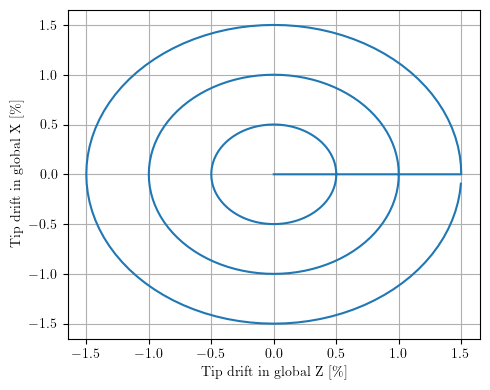

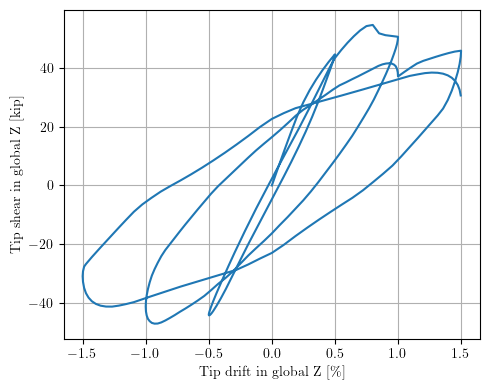

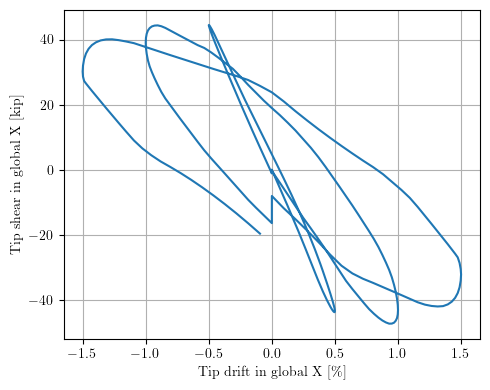

In [9]:
history = run_analysis()
# save_results(history)
plot_results(history)